In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import sys
from jaxtyping import Float, Array, PRNGKeyArray

jax.config.update("jax_enable_x64", True)
sys.path.insert(0, "..")

In [2]:
from ctt.bases import make_canonical_polynomials, make_fourier, make_legendre_polynomials, make_chebyshev_polynomials

d = 2
n_features = 2
basis = make_canonical_polynomials(dim=n_features)
# basis = make_legendre_polynomials(dim=n_features)
# basis = make_chebyshev_polynomials(dim=n_features)
# basis = make_fourier(n_features)
# basis = lambda x: jnp.asarray([1., jax.nn.relu(x)])
key = random.PRNGKey(42)

In [3]:
@jax.jit
def target(x: Float[Array, "d"]) -> Float[Array, "m"]:
    # val = jnp.exp(-jnp.sum(x**2)/2)
    # val = 1./(1. + jnp.mean(x))
    # val = jnp.mean(x**2)
    val = 1./(1+jnp.prod(x))
    # val = jnp.sum(jnp.sin(2*jnp.pi*x))
    # val = jnp.prod((x >= 0.)*1.)
    # val = jnp.mean(jnp.exp(x))
    # val = (jnp.linalg.norm(x) <= 1.) * 1.
    # def g(x, y):
    #     m = 3
    #     return jnp.sum((x*y)**jnp.arange(0, m+1))
    # z = jnp.sum(jnp.asarray([g(x[i], x[i+1]) for i in range(x.shape[0]-1)]))
    # val = jnp.log(1. + z)
    # val = jnp.log(1+ + jnp.sum(x**2))
    # val = 1./(10+2*x[0]+x[2]+2*x[3]-x[4])**2
    return jnp.atleast_1d(val)


In [4]:
from ctt.model import make_ctt

def lift(x: Float[Array, "d"]) -> Float[Array, "m"]:
    return jnp.hstack((0., x))

def retraction(x: Float[Array, "m"]) -> Float[Array, "o"]:
    return jnp.asarray((x[0],))

d_lift = jax.eval_shape(lift, jax.ShapeDtypeStruct((d,), dtype=float)).shape[0]
ctt = make_ctt(lift, retraction, basis, d)

In [5]:
key, train_key, val_key = random.split(key, 3)

domain = (0., 1.)
N_train = 10000
X_train = random.uniform(key=train_key, shape=(N_train, d), minval=domain[0], maxval=domain[1])
# X_train = random.normal(key=train_key, shape=(N_train, d))
y_train = jax.vmap(target)(X_train)

N_val = 2000
X_val = random.uniform(key=val_key, shape=(N_val, d), minval=domain[0], maxval=domain[1])
# X_val = random.normal(key=val_key, shape=(N_val, d))
y_val = jax.vmap(target)(X_val)

num_steps = 3
regularization_coeff = 0.
radius = None
ranks = [d_lift] + [2] * (d_lift-1) + [1]

In [6]:
def dataloader(arrays: list, batch_size: int, *, key: PRNGKeyArray):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = random.permutation(key, indices)
        (key,) = random.split(key, 1)
        start = 0
        end = batch_size
        while end < dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

In [7]:
import optax
from ctt.tt import tt_norm, TT

@jax.jit
def compute_loss(tts: list[TT],
                 x: Float[Array, "B d"],
                 y: Float[Array, "B d_o"],
                 alpha: float = 0.) -> tuple[float,float]:
    y_pred = jax.vmap(ctt, in_axes=(None, 0))(tts, x)
    # loss = jnp.mean(optax.l2_loss(y_pred, y))
    loss = jnp.mean(optax.l2_loss(y_pred, y))
    penalty = alpha*jnp.sum(jnp.asarray([tt_norm(u)**2 for u in tts]))
    return loss + penalty, loss

# Riemannian gradient descent

For computing the Riemannian gradient, we will use this paper https://arxiv.org/abs/2103.14974, which computes it using autodiff.

In [8]:
from ctt.tt import tt_dims, tt_ranks, tt_zeros, TTCore

def tt_zeros_like(x: TT) -> TT:
    dims = tt_dims(x)
    ranks = tt_ranks(x)
    return tt_zeros(dims, ranks)

def _shift_right(a: TTCore, b: TTCore) -> tuple[TTCore, TTCore]:
    c = jnp.reshape(a, (-1, a.shape[2]))
    q, r = jnp.linalg.qr(c)
    comp = jnp.reshape(q, (a.shape[0], a.shape[1], q.shape[1]))
    # comp_next = jnp.tensordot(r, b, axes=((1,), (0,)))
    comp_next = jnp.einsum("ij,jkl->ikl", r, b)
    return comp, comp_next

def _shift_left(a: TTCore, b: TTCore) -> tuple[TTCore, TTCore]:
    c = jnp.reshape(b, (b.shape[0], -1))
    q, r = jnp.linalg.qr(c.T)
    qT = q.T
    comp = jnp.reshape(qT, (qT.shape[0], b.shape[1], b.shape[2]))
    # comp_previous = jnp.tensordot(a, r, axes=((2,), (1,)))
    comp_previous = jnp.einsum("ijk,kl->ijl", a, r.T)
    return comp_previous, comp

def tt_orthogonalize(x: TT) -> tuple[TT, TT, TT]:
    d = len(x)
    U = [None]*(d-1)
    V = [None]*(d-1)
    S = [None]*d

    # first compute U_1, ..., U_d-1
    comp = x[0]
    for k in range(d-1):
        u, comp = _shift_right(comp, x[k+1])
        U[k] = u
    # we also get S_d
    S[-1] = comp
    # then, compute V_2,...,V_d
    for k in range(d-2, -1, -1):
        comp, v = _shift_left(U[k], comp)
        V[k] = v
        S[k] = comp
    
    return U, V, S


In [9]:
def _convert_delta_tt(U: TT, V: TT, S: TT, dot_S : TT) -> TT:
    # U_1,...,U_d-1
    # V_2,...,V_d,
    # S_1,...,S_d
    # U, V, S = tt_orthogonalize(x)

    G = [jnp.concatenate((dot_S[0], U[0]), axis=2)]
    for k in range(1, len(S) - 1):
        u, v, dot_s = U[k], V[k-1], dot_S[k]
        rm1, n, r = u.shape
        data = jnp.zeros((2*rm1, n, 2*r))
        data = data.at[:rm1, :, :r].set(v)
        data = data.at[rm1:, :, :r].set(dot_s)
        data = data.at[rm1:, :, r:].set(u)
        G.append(data)
    
    data = jnp.concatenate((V[-1][..., 0], dot_S[-1][..., 0]), axis=0)
    data = data[..., None]
    G.append(data)
    return G

def rgrad(f, product_manifold: bool = False, has_aux: bool = False):
    if product_manifold:
        def _g(R: list[TT], U: list[TT], V: list[TT], S: list[TT], *args, **kwargs):
            # tt = jax.tree.map(_convert_delta_tt, U, V, S, R)
            tt = [_convert_delta_tt(U[i], V[i], S[i], R[i]) for i in range(len(R))]
            return f(tt, *args, **kwargs)

        def _build_R(x, S):
            R = tt_zeros_like(x)
            R[0] = S[0]
            return R

        def _f(x, *args, **kwargs):
            # Us, Vs, Ss = list(zip(*jax.tree.map(tt_orthogonalize, x)))
            Us, Vs, Ss = list(zip(*map(tt_orthogonalize, x)))
            Rs = [_build_R(x[i], Ss[i]) for i in range(len(x))]

            if has_aux:
                grad, aux_data = jax.grad(_g, argnums=0, has_aux=True)(Rs, Us, Vs, Ss, *args, **kwargs)
            else:
                grad = jax.grad(_g, argnums=0, has_aux=False)(Rs, Us, Vs, Ss, *args, **kwargs)
            
            for i in range(len(x)):
                for k in range(len(x[i])-1):
                    dot_S = grad[i][k]
                    Dk = jnp.reshape(dot_S, (-1, dot_S.shape[2]))
                    UkL = jnp.reshape(Us[i][k], (-1, dot_S.shape[2]))
                    Dk = Dk - UkL @ (UkL.T @ Dk)
                    dot_S = jnp.reshape(Dk, grad[i][k].shape)
                    grad[i][k] = dot_S
            
            # riemannian_grad = jax.tree.map(_convert_delta_tt, Us, Vs, Ss, grad)
            riemannian_grad = [_convert_delta_tt(Us[i], Vs[i], Ss[i], grad[i]) for i in range(len(x))]

            if has_aux:
                return riemannian_grad, aux_data
            return riemannian_grad
    
    else:
        def _g(R: TT, U: TT, V: TT, S: TT, *args, **kwargs):
            tt = _convert_delta_tt(U, V, S, R)
            return f(tt, *args, **kwargs)

        def _f(x, *args, **kwargs):
            U, V, S = tt_orthogonalize(x)

            R = tt_zeros_like(x)
            R[0] = S[0]
            if has_aux:
                grad, aux_data = jax.grad(_g, argnums=0, has_aux=True)(R, U, V, S, *args, **kwargs)
            else:
                grad = jax.grad(_g, argnums=0, has_aux=False)(R, U, V, S, *args, **kwargs)
            
            for k in range(len(x)-1):
                dot_S = grad[k]
                Dk = jnp.reshape(dot_S, (-1, dot_S.shape[2]))
                UkL = jnp.reshape(U[k], (-1, dot_S.shape[2]))
                Dk = Dk - UkL @ (UkL.T @ Dk)
                dot_S = jnp.reshape(Dk, grad[k].shape)
                grad[k] = dot_S
            
            riemannian_grad = _convert_delta_tt(U, V, S, grad)

            if has_aux:
                return riemannian_grad, aux_data
            return riemannian_grad
    
    return _f

In [10]:
from typing import Callable, NamedTuple
from ctt.tt import tt_dot, tt_mul_scalar, tt_add
from functools import partial

def backtracking_linesearch(max_backtracking_steps: int,
                            slope_rtol: float = 1e-4,
                            decrease_factor: float = 0.8,
                            learning_rate: float = 1.,
                            atol: float = 0.,
                            rtol: float = 0.):
    def _compute_decrease_error(
            stepsize: float,
            slope: float,
            value: float,
            new_value: float
    ) -> float:
        decrease_error = new_value - (1.+rtol)*value - stepsize*slope_rtol*slope
        decrease_error = jnp.where(jnp.isnan(decrease_error), jnp.inf, decrease_error)
        return jnp.maximum(decrease_error, 0.)

    class State(NamedTuple):
        learning_rate: float
        new_value: float
        decrease_error: float
        iter_num: int

    def update_fn(updates: list[TT],
                  params: list[TT],
                  value: float,
                  grad: list[TT],
                  value_fn: Callable[[list[TT]], float]) -> list[TT]:
        d = len(updates)
        slope = sum(tt_dot(updates[i], grad[i]) for i in range(d))
        
        def cond_fn(state: State):
            decrease_error = state.decrease_error
            iter_num = state.iter_num
            return (~(decrease_error <= atol)) & (iter_num <= max_backtracking_steps)
        
        def body_fn(state: State):
            learning_rate = state.learning_rate
            iter_num = state.iter_num

            learning_rate = jnp.where(iter_num > 0, decrease_factor * learning_rate, learning_rate)
            scaled_updates = list(map(partial(tt_mul_scalar, val=-learning_rate), updates))
            new_params = list(map(tt_add, params, scaled_updates))

            new_value = value_fn(new_params)
            decrease_error = _compute_decrease_error(learning_rate, slope, value, new_value)

            state = State(
                learning_rate=learning_rate,
                new_value=new_value,
                decrease_error=decrease_error,
                iter_num=iter_num + 1
            )
            return state
        
        state = jax.lax.while_loop(cond_fn, body_fn, State(
            learning_rate=learning_rate,
            new_value=value,
            decrease_error=jnp.inf,
            iter_num=0
        ))
        new_learning_rate = jnp.where(jnp.isinf(state.decrease_error), 0., state.learning_rate)
        new_updates = list(map(partial(tt_mul_scalar, val=-new_learning_rate), updates))
        return new_updates
    
    return update_fn


In [11]:
from ctt.tt import tt_retract, tt_mul_scalar, tt_add

def riemannian_gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                                val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                                learning_rate: float,
                                params: list[TT],
                                opt_steps: int,
                                regularization_coeff: float,
                                training_key: PRNGKeyArray,
                                batch_size: int = 64,
                                backtraking: bool = False) -> tuple[list[TT], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    train_losses = []
    val_losses = []

    ranks = list(map(tt_ranks, params))
    if backtraking:
        linesearch = backtracking_linesearch(max_backtracking_steps=15,
                                             learning_rate=learning_rate)

    @jax.jit
    def step(tts: list[TT],
             x: Float[Array, "B d"],
             y: Float[Array, "B d"],
             alpha: float = 0.):
        grads, l2_error = rgrad(compute_loss, product_manifold=True, has_aux=True)(tts, x, y, alpha)
        # loss, l2_error = compute_loss(tts, x, y, alpha)
        if backtraking:
            updates = linesearch(grads, tts, l2_error, grads, lambda p: compute_loss(p, x, y, 0.)[1])
        else:
            updates = [tt_mul_scalar(grads[i], -learning_rate) for i in range(len(tts))]
        # params = optax.apply_updates(tts, updates)
        params = [tt_add(tts[i], updates[i]) for i in range(len(tts))]
        # don't forget to retract!
        params = [tt_retract(params[i], ranks[i]) for i in range(len(tts))]
        return params, l2_error

    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        params, l2_error = step(params, 
                               x,
                               y,
                               alpha=regularization_coeff)
        _, val_loss = compute_loss(params, X_val, y_val, alpha=0.)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")

    return params, (train_losses, val_losses)

# Performance

In [12]:
from ctt.tt import tt_zeros, tt_randn

key, *control_keys = random.split(key, num_steps+1)
key, training_key = random.split(key)

init_controls = [
    tt_randn(control_key, [n_features] * d_lift, ranks, cov=3.0)
    for control_key in control_keys
]
zero_init_controls = [
    tt_zeros([n_features] * d_lift, ranks)
    for _ in range(num_steps)
]
print(list(map(tt_norm, init_controls)))

[Array(0.29125693, dtype=float64), Array(0.24707065, dtype=float64), Array(0.88145618, dtype=float64)]


In [13]:
learning_rate = 1.
params_gd, (train_losses_gd, val_losses_gd) = riemannian_gradient_descent(train_dataset=(X_train, y_train),
                                                                          val_dataset=(X_val, y_val),
                                                                          learning_rate=learning_rate,
                                                                          params=init_controls,
                                                                          opt_steps=15000,
                                                                          regularization_coeff=regularization_coeff,
                                                                          batch_size=128,
                                                                          training_key=training_key,
                                                                          backtraking=True)

Iter 0 | Loss: 2.175e-01 | Val loss: 2.103e-01
Iter 5 | Loss: 1.349e-02 | Val loss: 8.482e-03
Iter 10 | Loss: 1.866e-03 | Val loss: 1.660e-03
Iter 15 | Loss: 8.101e-04 | Val loss: 6.639e-04
Iter 20 | Loss: 4.479e-04 | Val loss: 4.282e-04
Iter 25 | Loss: 3.609e-04 | Val loss: 3.764e-04
Iter 30 | Loss: 4.612e-04 | Val loss: 4.591e-04
Iter 35 | Loss: 3.207e-04 | Val loss: 3.366e-04
Iter 40 | Loss: 4.566e-04 | Val loss: 3.969e-04
Iter 45 | Loss: 4.632e-04 | Val loss: 4.669e-04
Iter 50 | Loss: 3.000e-04 | Val loss: 3.162e-04
Iter 55 | Loss: 3.375e-04 | Val loss: 3.061e-04
Iter 60 | Loss: 3.104e-04 | Val loss: 2.784e-04
Iter 65 | Loss: 2.548e-04 | Val loss: 2.825e-04
Iter 70 | Loss: 2.724e-04 | Val loss: 2.610e-04
Iter 75 | Loss: 2.758e-04 | Val loss: 2.440e-04
Iter 80 | Loss: 2.968e-04 | Val loss: 2.454e-04
Iter 85 | Loss: 2.085e-04 | Val loss: 2.291e-04
Iter 90 | Loss: 2.955e-04 | Val loss: 2.921e-04
Iter 95 | Loss: 2.056e-04 | Val loss: 2.231e-04
Iter 100 | Loss: 1.691e-04 | Val loss: 2.1

Text(0, 0.5, 'Error')

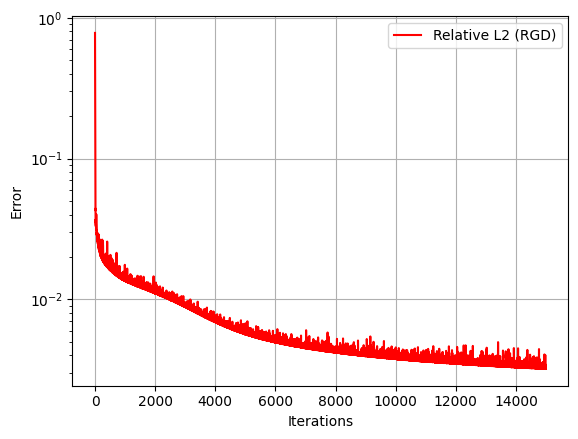

In [14]:
fig, ax = plt.subplots()

y_val_norm = jnp.mean(optax.l2_loss(jnp.zeros_like(y_val), y_val))

# plot RGD losses
val_losses_gd = jnp.asarray(val_losses_gd)

ax.semilogy(jnp.arange(len(val_losses_gd)), jnp.sqrt(val_losses_gd/y_val_norm), label="Relative L2 (RGD)", color="red")

ax.grid()
ax.legend()
ax.set_xlabel("Iterations")
ax.set_ylabel("Error")